# 지역별 수요 강도 분석 

서울시 장애인콜택시 이용 데이터를 자치구 단위로 집계하여 지역별 수요 강도를 비교한다. 단순 접수건수와 탑승건수뿐 아니라 장애인 인구 대비 이용건수를 함께 계산하여, 절대 수요가 높은 지역과 인구 대비 이용 강도가 높은 지역을 구분한다.

In [1]:
import json
import platform
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

In [2]:
# 프로젝트 루트 설정
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_DIR = DATA_DIR / "raw"

request_path = PROCESSED_DIR / "서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv"
boarding_path = PROCESSED_DIR / "서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv"
disabled_population_path = RAW_DIR / "서울시장애인현황(등급별_동별)_20260825160404.csv"

df_request = pd.read_csv(request_path)
df_boarding = pd.read_csv(boarding_path)
df_disabled_population = pd.read_csv(disabled_population_path)

print(f"df_request: {df_request.shape}")
print(f"df_boarding: {df_boarding.shape}")
print(f"df_disabled_population: {df_disabled_population.shape}")

df_request: (1722490, 22)
df_boarding: (1722490, 15)
df_disabled_population: (481, 12)


## 01. 데이터 전처리

접수 데이터에서 접수일시, 예정일시, 배차일시, 승차일시, 하차일시, 취소일시를 datetime으로 변환

In [3]:
df_boarding.info()

<class 'pandas.DataFrame'>
RangeIndex: 1722490 entries, 0 to 1722489
Data columns (total 15 columns):
 #   Column  Dtype  
---  ------  -----  
 0   접수일시    str    
 1   예정일시    str    
 2   배차일시    str    
 3   승차일시    str    
 4   하차일시    str    
 5   취소일시    str    
 6   출발구     str    
 7   출발동     str    
 8   목적구     str    
 9   목적동     str    
 10  이용목적    str    
 11  요금      float64
 12  승차거리    int64  
 13  차량구분    str    
 14  장애유형    str    
dtypes: float64(1), int64(1), str(13)
memory usage: 197.1 MB


In [4]:
datetime_cols = [
    "접수일시",
    "예정일시",
    "배차일시",
    "승차일시",
    "하차일시",
    "취소일시",
]

for col in datetime_cols:
    df_boarding[col] = pd.to_datetime(df_boarding[col], errors="coerce")

for col in datetime_cols:
    print(f"{col} 결측/변환실패: {df_boarding[col].isna().sum():,}건")

접수일시 결측/변환실패: 0건
예정일시 결측/변환실패: 0건
배차일시 결측/변환실패: 177,594건
승차일시 결측/변환실패: 245,361건
하차일시 결측/변환실패: 245,423건
취소일시 결측/변환실패: 1,477,193건


### 출발구 결측치 및 이상값 확인

지역별 수요 강도 분석에서는 `출발구`를 기준으로 자치구별 접수건수와 탑승건수를 집계          
따라서 `출발구`가 비어 있거나 서울시 25개 자치구에 해당하지 않는 값이 있는지 먼저 확인

In [5]:
seoul_districts = [
    "종로구", "중구", "용산구", "성동구", "광진구",
    "동대문구", "중랑구", "성북구", "강북구", "도봉구",
    "노원구", "은평구", "서대문구", "마포구", "양천구",
    "강서구", "구로구", "금천구", "영등포구", "동작구",
    "관악구", "서초구", "강남구", "송파구", "강동구",
]

missing_departure_region_count = df_boarding["출발구"].isna().sum()

invalid_departure_region = df_boarding[
    df_boarding["출발구"].notna()
    & ~df_boarding["출발구"].isin(seoul_districts)
]

print(f"출발구 결측치: {missing_departure_region_count:,}건")
print(f"서울시 25개 자치구 외 출발구: {len(invalid_departure_region):,}건")

display(
    df_boarding["출발구"]
    .value_counts(dropna=False)
    .rename_axis("출발구")
    .reset_index(name="건수")
)

if len(invalid_departure_region) > 0:
    display(
        invalid_departure_region["출발구"]
        .value_counts()
        .rename_axis("출발구")
        .reset_index(name="건수")
    )

출발구 결측치: 1건
서울시 25개 자치구 외 출발구: 7,617건


,출발구,건수
0,노원구,175718
1,강서구,116052
2,강동구,102059
3,서대문구,95942
4,은평구,94758
5,마포구,94583
6,송파구,71928
7,영등포구,71742
8,강남구,69820
9,중랑구,67626


,출발구,건수
0,김포시,1358
1,남양주시,1202
2,고양시덕양구,722
3,하남시,673
4,고양시일산동구,557
5,성남시분당구,487
6,양주시,487
7,의정부시,387
8,광명시,294
9,구리시,258


In [6]:
df_boarding[df_boarding["출발구"].isna()]

,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
233730,2025-02-25 09:40:31,2025-02-25 09:41:00,NaT,NaT,NaT,2025-02-25 09:40:34,NaN,NaN,NaN,NaN,기타,NaN,0,특장차,뇌병


#### 출발구 결측 행 제거

지역별 수요 강도 분석은 `출발구`를 기준으로 자치구별 접수건수와 탑승건수를 집계        
`출발구`가 결측인 행은 특정 자치구에 배정할 수 없으므로 분석 대상에서 제외    

In [7]:
missing_departure_region = df_boarding[df_boarding["출발구"].isna()]

display(missing_departure_region)

before_rows = len(df_boarding)

df_boarding = df_boarding.dropna(subset=["출발구"]).copy()

after_rows = len(df_boarding)

print(f"삭제 전 행 수: {before_rows:,}")
print(f"삭제 후 행 수: {after_rows:,}")
print(f"삭제된 행 수: {before_rows - after_rows:,}")

,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
233730,2025-02-25 09:40:31,2025-02-25 09:41:00,NaT,NaT,NaT,2025-02-25 09:40:34,NaN,NaN,NaN,NaN,기타,NaN,0,특장차,뇌병


삭제 전 행 수: 1,722,490
삭제 후 행 수: 1,722,489
삭제된 행 수: 1


### 출발구와 목적구의 서울 외 지역 여부 확인

지역별 수요 분석에서는 서울시 자치구를 기준으로 수요를 집계한다.  
따라서 `출발구`가 서울시 25개 자치구에 포함되지 않는 행 중에서 `목적구`도 서울시 자치구가 아닌 경우가 있는지 확인한다.  
이 값들은 서울 내부 이동 수요로 보기 어렵기 때문에 별도 검토가 필요하다.

In [8]:
seoul_districts = [
    "종로구", "중구", "용산구", "성동구", "광진구",
    "동대문구", "중랑구", "성북구", "강북구", "도봉구",
    "노원구", "은평구", "서대문구", "마포구", "양천구",
    "강서구", "구로구", "금천구", "영등포구", "동작구",
    "관악구", "서초구", "강남구", "송파구", "강동구",
]

non_seoul_departure = df_boarding[
    df_boarding["출발구"].notna()
    & ~df_boarding["출발구"].isin(seoul_districts)
].copy()

non_seoul_departure_and_destination = non_seoul_departure[
    non_seoul_departure["목적구"].notna()
    & ~non_seoul_departure["목적구"].isin(seoul_districts)
].copy()

print(f"출발구가 서울 외 지역인 행 수: {len(non_seoul_departure):,}건")
print(
    "출발구와 목적구가 모두 서울 외 지역인 행 수: "
    f"{len(non_seoul_departure_and_destination):,}건"
)

display(
    non_seoul_departure_and_destination[
        ["접수일시", "출발구", "목적구", "승차일시", "취소일시"]
    ].head(20)
)

display(
    non_seoul_departure_and_destination[["출발구", "목적구"]]
    .value_counts()
    .reset_index(name="건수")
)

출발구가 서울 외 지역인 행 수: 7,617건
출발구와 목적구가 모두 서울 외 지역인 행 수: 80건


,접수일시,출발구,목적구,승차일시,취소일시
984,2025-01-01 15:03:21,과천시,의정부시,2025-01-01 15:24:57.307,NaT
15695,2025-01-05 15:15:05,광명시,성남시분당구,2025-01-05 16:02:29.240,NaT
38331,2025-01-10 01:41:49,의정부시,의정부시,2025-01-10 02:32:02.833,NaT
47347,2025-01-12 15:04:28,광명시,성남시분당구,2025-01-12 15:36:12.013,NaT
79368,2025-01-19 15:04:23,광명시,성남시분당구,2025-01-19 15:49:52.647,NaT
118695,2025-01-30 12:36:14,과천시,의정부시,2025-01-30 13:00:54.663,NaT
128968,2025-02-03 07:08:15,광주시,광주시,NaT,2025-02-03 07:08:19
140179,2025-02-04 18:13:22,의정부시,의정부시,2025-02-04 19:37:35.467,NaT
159272,2025-02-08 15:21:52,남양주시,남양주시,2025-02-08 16:38:04.510,NaT
169650,2025-02-10 07:10:14,연수구,연수구,NaT,2025-02-10 07:10:18


,출발구,목적구,건수
0,구리시,남양주시,13
1,의정부시,의정부시,11
2,남양주시,남양주시,6
3,과천시,의정부시,5
4,하남시,성남시분당구,4
5,광명시,성남시분당구,3
6,성남시중원구,성남시중원구,3
7,하남시,하남시,3
8,광주시,광주시,2
9,구리시,구리시,2


### 출발구와 목적구가 모두 서울 외 지역인 행 제거

지역별 수요 분석은 서울시 자치구를 기준으로 수행한다.  
`출발구`와 `목적구`가 모두 서울시 25개 자치구에 포함되지 않는 행은 서울 내부 수요로 보기 어렵기 때문에 분석 대상에서 제외한다.

In [9]:
before_rows = len(df_boarding)

non_seoul_both_mask = (
    df_boarding["출발구"].notna()
    & df_boarding["목적구"].notna()
    & ~df_boarding["출발구"].isin(seoul_districts)
    & ~df_boarding["목적구"].isin(seoul_districts)
)

removed_non_seoul_both = df_boarding[non_seoul_both_mask].copy()

display(
    removed_non_seoul_both[
        ["접수일시", "출발구", "목적구", "승차일시", "취소일시"]
    ].head(20)
)

df_boarding = df_boarding.loc[~non_seoul_both_mask].copy()

after_rows = len(df_boarding)

print(f"삭제 전 행 수: {before_rows:,}")
print(f"삭제 후 행 수: {after_rows:,}")
print(f"삭제된 행 수: {before_rows - after_rows:,}")

,접수일시,출발구,목적구,승차일시,취소일시
984,2025-01-01 15:03:21,과천시,의정부시,2025-01-01 15:24:57.307,NaT
15695,2025-01-05 15:15:05,광명시,성남시분당구,2025-01-05 16:02:29.240,NaT
38331,2025-01-10 01:41:49,의정부시,의정부시,2025-01-10 02:32:02.833,NaT
47347,2025-01-12 15:04:28,광명시,성남시분당구,2025-01-12 15:36:12.013,NaT
79368,2025-01-19 15:04:23,광명시,성남시분당구,2025-01-19 15:49:52.647,NaT
118695,2025-01-30 12:36:14,과천시,의정부시,2025-01-30 13:00:54.663,NaT
128968,2025-02-03 07:08:15,광주시,광주시,NaT,2025-02-03 07:08:19
140179,2025-02-04 18:13:22,의정부시,의정부시,2025-02-04 19:37:35.467,NaT
159272,2025-02-08 15:21:52,남양주시,남양주시,2025-02-08 16:38:04.510,NaT
169650,2025-02-10 07:10:14,연수구,연수구,NaT,2025-02-10 07:10:18


삭제 전 행 수: 1,722,489
삭제 후 행 수: 1,722,409
삭제된 행 수: 80


## 02. 자치구별 분석

### 자치구별 접수건수 확인

*“서울 안에서 장애인콜택시 요청이 어디에 집중되는가”*

지역별 수요 강도 분석을 위해 `출발구`를 기준으로 자치구별 접수건수를 집계한다.  
접수건수는 각 자치구에서 장애인콜택시 이용 요청이 얼마나 발생했는지 보여주는 기본 수요 지표다.

In [10]:
region_request_count = (
    df_boarding
    .dropna(subset=["출발구"])
    .groupby("출발구")
    .size()
    .reset_index(name="접수건수")
    .sort_values("접수건수", ascending=False)
    .reset_index(drop=True)
)

print(f"집계 자치구 수: {region_request_count['출발구'].nunique():,}개")
display(region_request_count)

집계 자치구 수: 53개


,출발구,접수건수
0,노원구,175718
1,강서구,116052
2,강동구,102059
3,서대문구,95942
4,은평구,94758
5,마포구,94583
6,송파구,71928
7,영등포구,71742
8,강남구,69820
9,중랑구,67626


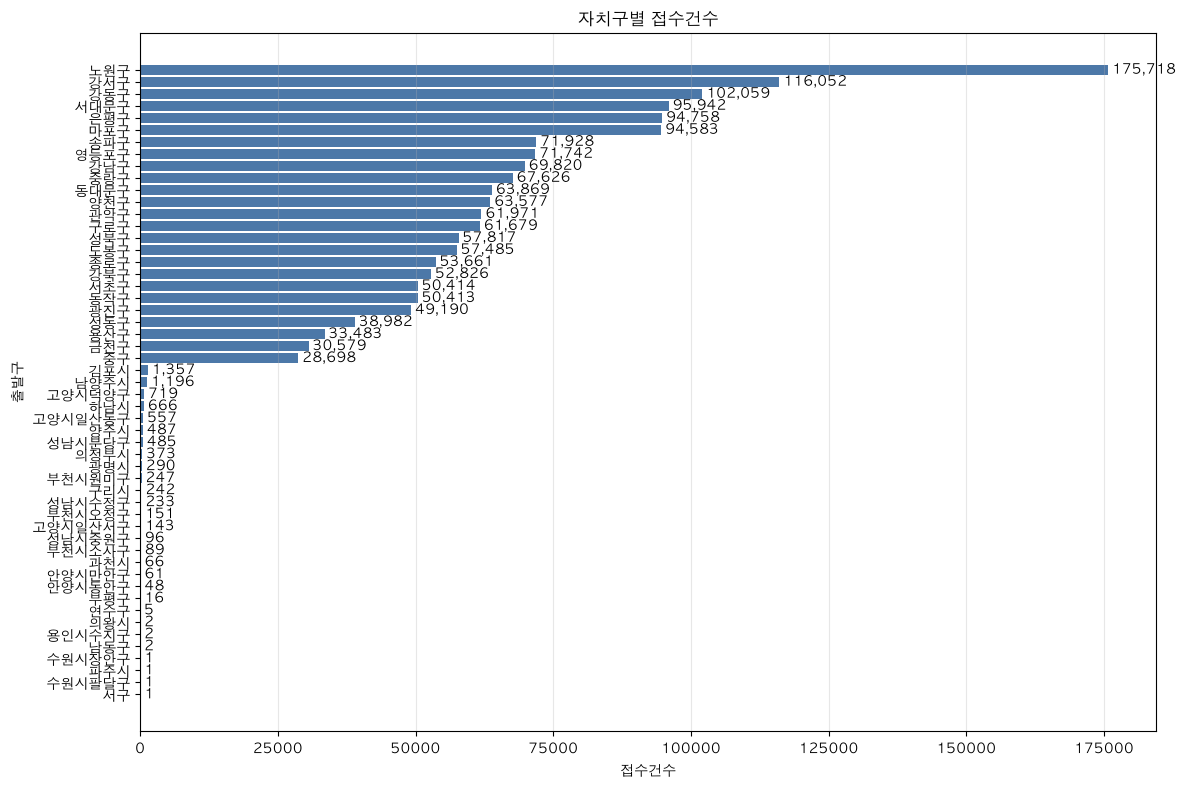

In [11]:
plt.figure(figsize=(12, 8))

plot_data = region_request_count.sort_values("접수건수", ascending=True)

plt.barh(plot_data["출발구"], plot_data["접수건수"], color="#4c78a8")
plt.title("자치구별 접수건수")
plt.xlabel("접수건수")
plt.ylabel("출발구")
plt.grid(axis="x", alpha=0.3)

for index, value in enumerate(plot_data["접수건수"]):
    plt.text(value, index, f" {value:,.0f}", va="center")

plt.tight_layout()
plt.show()

### 서울 자치구 기준 접수건수 확인

현재 데이터의 `출발구`에는 서울시 자치구가 아닌 지역도 포함되어 있다.  
이번 단계에서는 서울시 25개 자치구만 대상으로 필터링하여 자치구별 접수건수를 확인한다.  
서울 외 출발 또는 목적 이동은 이후 `서울→서울 외`, `서울 외→서울` 흐름으로 별도 분석한다.

In [12]:
seoul_districts = [
    "종로구", "중구", "용산구", "성동구", "광진구",
    "동대문구", "중랑구", "성북구", "강북구", "도봉구",
    "노원구", "은평구", "서대문구", "마포구", "양천구",
    "강서구", "구로구", "금천구", "영등포구", "동작구",
    "관악구", "서초구", "강남구", "송파구", "강동구",
]

df_boarding_seoul_departure = df_boarding[
    df_boarding["출발구"].isin(seoul_districts)
].copy()

region_request_count = (
    df_boarding_seoul_departure
    .groupby("출발구")
    .size()
    .reset_index(name="접수건수")
    .sort_values("접수건수", ascending=False)
    .reset_index(drop=True)
)

print(f"서울 출발 접수건수: {len(df_boarding_seoul_departure):,}건")
print(f"집계 자치구 수: {region_request_count['출발구'].nunique():,}개")

display(region_request_count)

서울 출발 접수건수: 1,714,872건
집계 자치구 수: 25개


,출발구,접수건수
0,노원구,175718
1,강서구,116052
2,강동구,102059
3,서대문구,95942
4,은평구,94758
5,마포구,94583
6,송파구,71928
7,영등포구,71742
8,강남구,69820
9,중랑구,67626


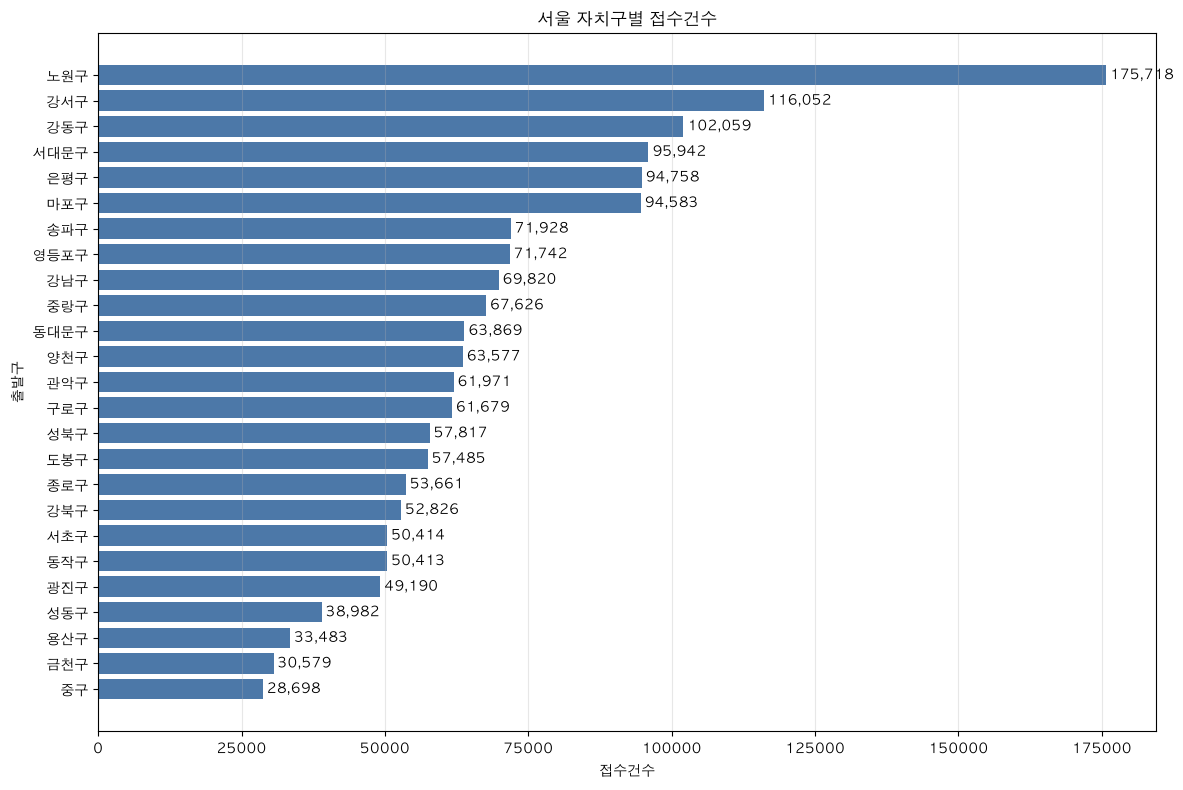

In [13]:
# 서울 외 지역은 제외했으므로, 광역 이동 수요는 이 그래프에 반영되지 않음

plt.figure(figsize=(12, 8))

plot_data = region_request_count.sort_values("접수건수", ascending=True)

plt.barh(plot_data["출발구"], plot_data["접수건수"], color="#4c78a8")
plt.title("서울 자치구별 접수건수")
plt.xlabel("접수건수")
plt.ylabel("출발구")
plt.grid(axis="x", alpha=0.3)

for index, value in enumerate(plot_data["접수건수"]):
    plt.text(value, index, f" {value:,.0f}", va="center")

plt.tight_layout()
plt.show()

### 서울 자치구별 일평균 접수건수 확인

자치구별 전체 접수건수는 기간이 길수록 누적 규모가 커지므로, 하루 평균 기준으로 변환해 지역별 수요 강도를 비교한다.  
`접수일시` 기준 일자별 접수건수를 먼저 집계한 뒤, 자치구별 평균을 계산한다.

In [14]:
df_boarding_seoul_departure = df_boarding[
    df_boarding["출발구"].isin(seoul_districts)
].copy()

df_boarding_seoul_departure["접수일자"] = pd.to_datetime(
    df_boarding_seoul_departure["접수일시"],
    errors="coerce",
).dt.date

daily_region_request_count = (
    df_boarding_seoul_departure
    .dropna(subset=["접수일자"])
    .groupby(["출발구", "접수일자"])
    .size()
    .reset_index(name="일별접수건수")
)

region_daily_avg_request_count = (
    daily_region_request_count
    .groupby("출발구")["일별접수건수"]
    .mean()
    .reset_index(name="일평균접수건수")
    .sort_values("일평균접수건수", ascending=False)
    .reset_index(drop=True)
)

print(f"집계 자치구 수: {region_daily_avg_request_count['출발구'].nunique():,}개")
display(region_daily_avg_request_count)

집계 자치구 수: 25개


,출발구,일평균접수건수
0,노원구,480.103825
1,강서구,317.081967
2,강동구,278.849727
3,서대문구,262.136612
4,은평구,258.901639
5,마포구,258.423497
6,영등포구,196.553425
7,송파구,196.524590
8,강남구,190.765027
9,중랑구,184.770492


In [15]:
df_boarding["접수일시"] = pd.to_datetime(df_boarding["접수일시"], errors="coerce")
df_boarding["예정일시"] = pd.to_datetime(df_boarding["예정일시"], errors="coerce")

same_request_scheduled = df_boarding["접수일시"].eq(df_boarding["예정일시"])

print(f"전체 행 수: {len(df_boarding):,}")
print(f"접수일시 = 예정일시: {same_request_scheduled.sum():,}건")
print(f"접수일시 != 예정일시: {(~same_request_scheduled).sum():,}건")
print(f"접수일시 결측: {df_boarding['접수일시'].isna().sum():,}건")
print(f"예정일시 결측: {df_boarding['예정일시'].isna().sum():,}건")

display(
    df_boarding.loc[
        ~same_request_scheduled,
        ["접수일시", "예정일시", "배차일시", "승차일시", "취소일시", "출발구", "목적구"]
    ].head(20)
)

전체 행 수: 1,722,409
접수일시 = 예정일시: 885,913건
접수일시 != 예정일시: 836,496건
접수일시 결측: 0건
예정일시 결측: 0건


,접수일시,예정일시,배차일시,승차일시,취소일시,출발구,목적구
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,NaT,노원구,노원구
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,NaT,영등포구,중구
5,2025-01-01 00:05:54.000,2025-01-01 00:06:00,2025-01-01 00:16:19.457,2025-01-01 00:54:19.940,NaT,서초구,서초구
9,2025-01-01 00:14:18.000,2025-01-01 00:15:00,2025-01-01 01:33:07.427,2025-01-01 01:54:19.933,NaT,성북구,도봉구
10,2025-01-01 00:14:55.597,2025-01-01 00:15:00,NaT,NaT,2025-01-01 00:21:09,강동구,강동구
12,2025-01-01 00:27:15.000,2025-01-01 00:28:00,NaT,NaT,2025-01-01 00:59:21,성북구,부천시원미구
13,2025-01-01 00:28:20.117,2025-01-01 00:28:00,2025-01-01 01:46:00.000,2025-01-01 02:01:00.000,NaT,종로구,노원구
14,2025-01-01 00:28:16.000,2025-01-01 00:29:00,2025-01-01 00:51:49.830,2025-01-01 01:06:28.367,NaT,노원구,노원구
16,2025-01-01 00:29:46.000,2025-01-01 00:30:00,2025-01-01 01:25:01.740,2025-01-01 01:48:17.233,NaT,영등포구,은평구
18,2025-01-01 00:30:31.000,2025-01-01 00:31:00,2025-01-01 01:38:03.127,2025-01-01 01:52:35.423,NaT,영등포구,은평구
